## LAB 4 - TASK 2 submission. ML 2025-26.


FILL UP THIS BOX WITH YOUR DETAILS

**NAME AND NIP**: Jorge Ruiz (826685) and Hugo López (875455)


### FILL UP THIS BRIEF DESCRIPTION of your TOY DATASET:

* Number of Classes: 5
* Name of the classes: cheesecake, chicken_quesadilla, chicken_wings, churros, donuts
* Source of the classes: https://www.kaggle.com/kmader/food41/version/5c

## Training from scratch

In this exercise we are building a small conv net to train from scratch using Tensorflow.Keras APIs

## Get data and tensorflow imports ready

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt

In [ ]:
# GET YOUR IMAGES READY

# OPTION A: upload and unzip, untar ... images if necessary (not recommended ... it'll only last one session)
from google.colab import files
uploaded = files.upload()
## 'uploaded' is a dictionary. You can get the file content like this:
for filename, content in uploaded.items():
    print(f"Uploaded {filename} with {len(content)} bytes")
##!tar -xvzf images.tar.gz
!unzip dataset.zip
!ls

# OPTION B: mount your google drive to point the code to find the data in your drive folders
# (instructions here: https://colab.research.google.com/notebooks/io.ipynb#scrollTo=u22w3BFiOveA)
#from google.colab import drive
#drive.mount('/content/drive')
## This assumes your file is in your main "My Drive" folder
## Adjust the path as needed! This will mount the data into a folder on a local drive for faster access
#!unzip "/content/drive/My Drive/toy-data.zip" -d "/content/dataset"

In [23]:
# SOME HELPER FUNCTIONS TO VISUALIZE RESULTS
def vis_history(results_history, epochs=10):
    acc = results_history.history['accuracy']
    val_acc = results_history.history['val_accuracy']

    loss = results_history.history['loss']
    val_loss = results_history.history['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()



## Definning and training the CNN
You need to train 3 versions of this model:
* First run and train the model given here by default.
* Then evaluate what happens if you remove Dropout layer and train again.
* Then add code to incorporate image augmentation to the network training.

Use this example to see how to easily add data augmentation as an additional layer to your model. https://www.tensorflow.org/tutorials/images/classification#data_augmentation

Think what data augmentation could be interesting for your classes and program the layer to get it.

In [6]:
####### ***** TO-DO-LAB *****  #######
# make sure you config these params to fit what you want/need

# dimensions of our images.
img_width, img_height = 150, 150
# MODIFY THE PATH TO POINT TO YOUR DATA! locally here or in your mounted drive
# get and print the actual working directory to make sure you are pointing to the right place
import os
print("Current working directory:", os.getcwd())

data_dir = './images/' # all in one folder and let the system do the split
epochs = 10 # UPDATE WITH YOUR NUMBERS!!
batch_size = 4
num_classes = 5
####### ***** TO-DO-LAB *****  #######

if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="both",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# for more optimized handling of the data
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

model.save_weights('first_try.weights.h5')

Current working directory: c:\Users\hugol\Documents\_UNIZAR\master\AI\B1---Artificial-Intelligence\Lab Sessions\Lab3
Found 5000 files belonging to 5 classes.
Using 4000 files for training.
Using 1000 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,565 (10.22 MB)

 Trainable params: 2,678,565 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.3047 - loss: 1.5373 - val_accuracy: 0.3990 - val_loss: 1.5092
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4680 - loss: 1.3103 - val_accuracy: 0.4250 - val_loss: 1.3422
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.5638 - loss: 1.0953 - val_accuracy: 0.4250 - val_loss: 1.4058
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.7150 - loss: 0.7545 - val_accuracy: 0.4210 - val_loss: 1.5971
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.8700 - loss: 0.3693 - val_accuracy: 0.4360 - val_loss: 2.3250
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9505 - loss: 0.1519 - val_accuracy: 0.4000 - val_loss: 3.5146
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9735 - loss: 0.0953 - val_accuracy: 0.4090 - val_loss: 4.8177
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9718 -

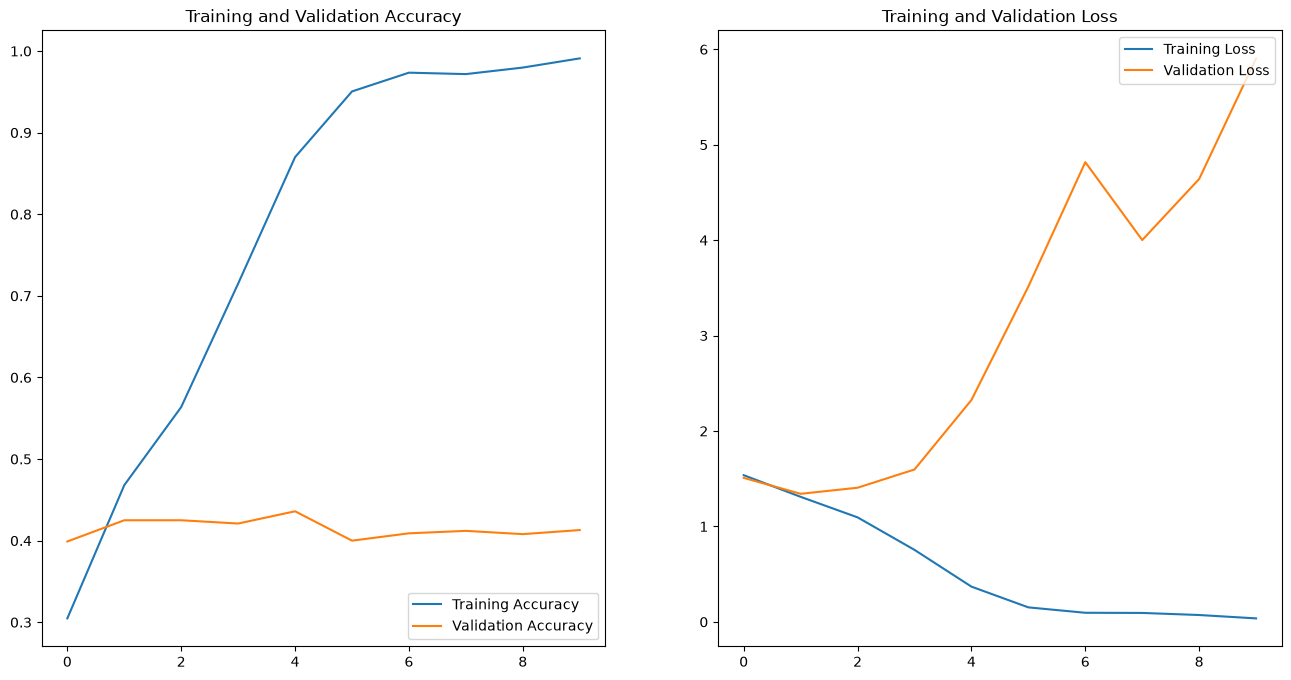

In [7]:
# VISUALIZE INITIAL RESULTS
vis_history(history)

There is a clear overfitting in this scenario. To solve it we include dropout to the model. 

### Model 2

In [15]:
#### *************** TO-DO-LAB3 *************** ####
# DEFINE a BETTER MODEL that INCLUDES DROPOUT, compile it and train it
model2 = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  
  # Añadimos un Dropout fuerte para frenar el cuello de botella tras el Flatten
  layers.Dropout(0.5),  
  layers.Dense(128, activation='relu'),
  
  # Añadimos un segundo Dropout antes de la capa de salida para evitar co-adaptación
  layers.Dropout(0.5),  
  layers.Dense(num_classes)
])

model2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model2.summary()

history2 = model2.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

#### *************** END TO-DO-LAB3 *************** ####


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,565 (10.22 MB)

 Trainable params: 2,678,565 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.3207 - loss: 1.5312 - val_accuracy: 0.3540 - val_loss: 1.4643
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4200 - loss: 1.3843 - val_accuracy: 0.4240 - val_loss: 1.3658
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.4577 - loss: 1.3171 - val_accuracy: 0.4490 - val_loss: 1.3201
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4952 - loss: 1.2545 - val_accuracy: 0.4670 - val_loss: 1.2818
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.5353 - loss: 1.1617 - val_accuracy: 0.4540 - val_loss: 1.3259
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.5725 - loss: 1.0813 - val_accuracy: 0.4590 - val_loss: 1.3724
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.6093 - loss: 0.9875 - val_accuracy: 0.4740 - val_loss: 1.3437
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.6562 -

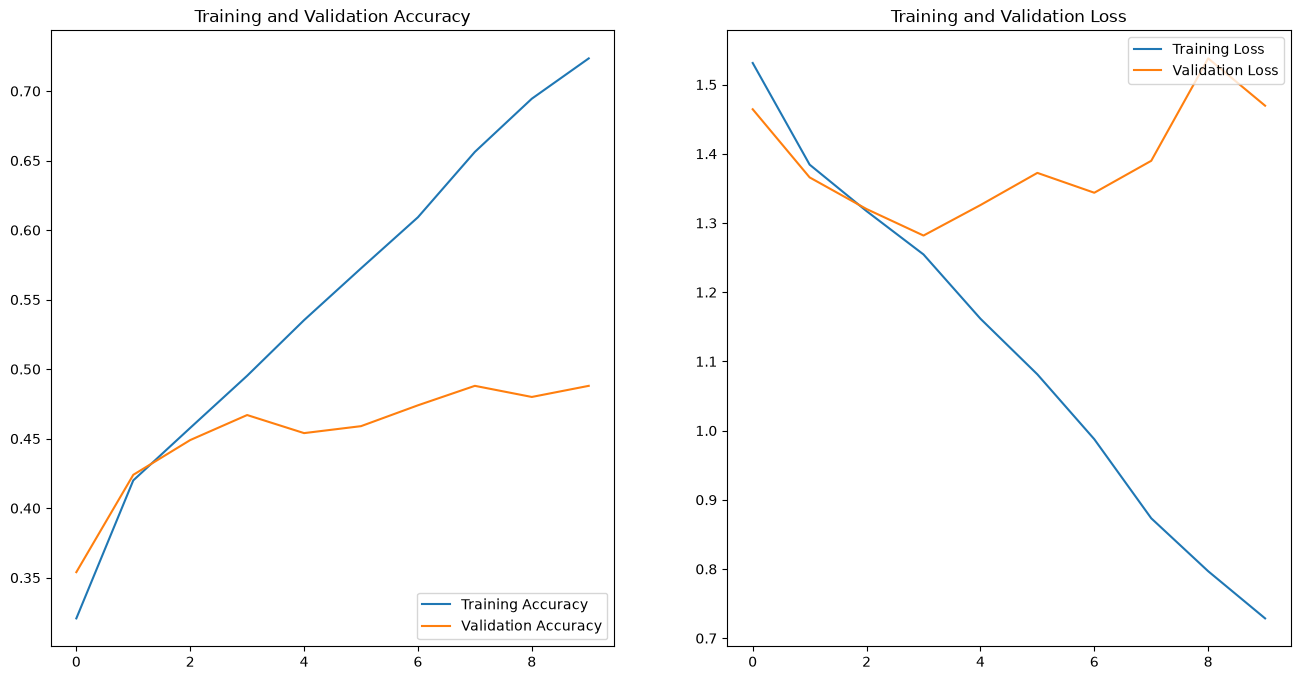

In [ ]:
# VISUALIZE RESULTS WITH DROPOUT
vis_history(history2)

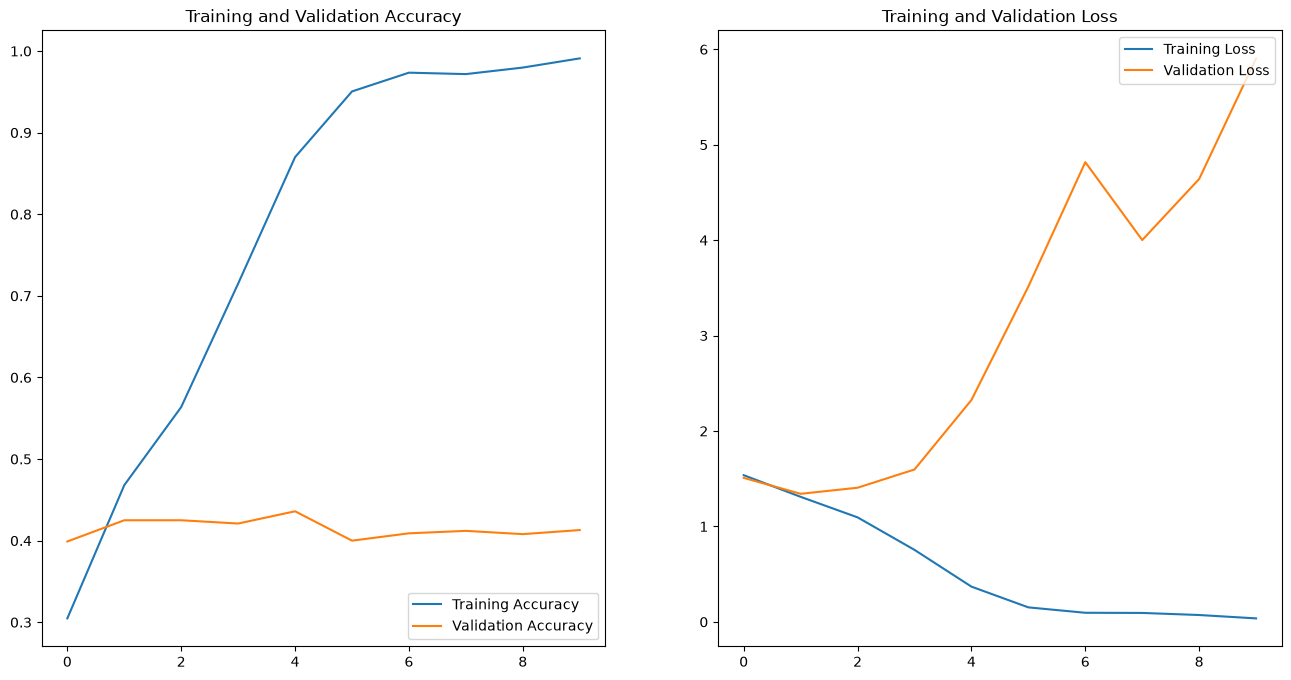

In [19]:
# PLOT HERE YOUR RESULTS WITHOUT DROPOUT
vis_history(history)

### Model 3

In [25]:
#### *************** TO-DO-LAB3 *************** ####
# DEFINE a BETTER MODEL that INCLUDES DROPOUT AND AUGMENTATION, compile it and train it

data_augmentation = Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.15),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1)
])

model3 = Sequential([
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  
  # Añadimos un Dropout fuerte para frenar el cuello de botella tras el Flatten
  layers.Dropout(0.5),  
  layers.Dense(128, activation='relu'),
  
  # Añadimos un segundo Dropout antes de la capa de salida para evitar co-adaptación
  layers.Dropout(0.5),  
  layers.Dense(num_classes)
])

model3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model3.summary()

history3 = model3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs+10
)
#### *************** END TO-DO-LAB3 *************** ####


c:\Users\hugol\anaconda3\envs\ai-lab\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\hugol\anaconda3\envs\ai-lab\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.3043 - loss: 1.5541 - val_accuracy: 0.3670 - val_loss: 1.4473
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.3713 - loss: 1.4506 - val_accuracy: 0.3700 - val_loss: 1.4700
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.3988 - loss: 1.4140 - val_accuracy: 0.4270 - val_loss: 1.4038
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.4002 - loss: 1.3965 - val_accuracy: 0.4090 - val_loss: 1.3785
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.4095 - loss: 1.3677 - val_accuracy: 0.4440 - val_loss: 1.3237
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.4363 - loss: 1.3363 - val_accuracy: 0.4340 - val_loss: 1.3103
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.4462 - loss: 1.3250 - val_accuracy: 0.4790 - val_loss: 1.2753
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.4577 - loss: 1.30

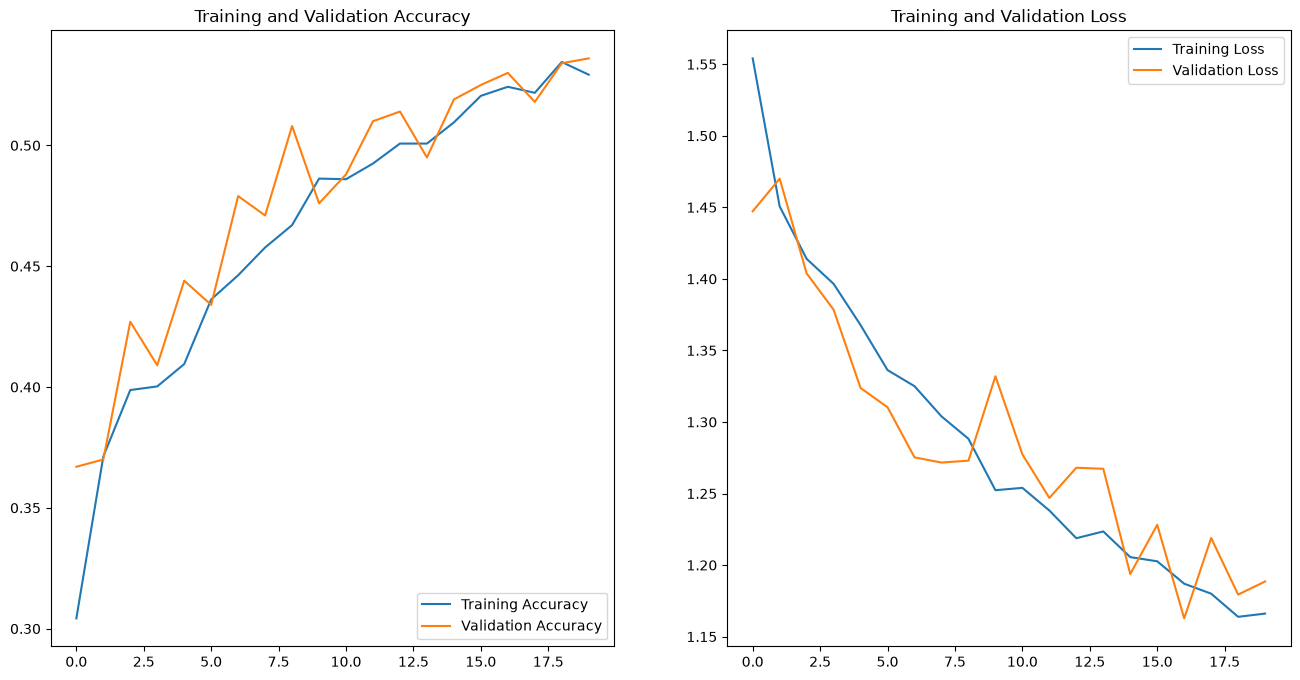

In [26]:
# PLOT HERE YOUR RESULTS INCLUDING DROPOUT and AUGMENTATION
vis_history(history3, 20)

In [27]:
model4 = Sequential([
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  
  # Más filtros iniciales
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  # Capa profunda más grande para detectar patrones complejos de comida
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  
  # Clasificador más grande protegido con Dropout
  layers.Dropout(0.4),  
  layers.Dense(256, activation='relu'), # Subimos a 256 neuronas
  
  layers.Dropout(0.3),  
  layers.Dense(num_classes)
])

model4.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model4.summary()

history4 = model4.fit(
  train_ds,
  validation_data=val_ds,
  epochs=20
)
#### *************** END TO-DO-LAB4 *************** ####

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,711,621 (40.86 MB)

 Trainable params: 10,711,621 (40.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.2915 - loss: 1.5535 - val_accuracy: 0.3680 - val_loss: 1.4615
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.3675 - loss: 1.4509 - val_accuracy: 0.3890 - val_loss: 1.4147
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 80s 80ms/step - accuracy: 0.3910 - loss: 1.4162 - val_accuracy: 0.4300 - val_loss: 1.3541
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 79s 79ms/step - accuracy: 0.4132 - loss: 1.3876 - val_accuracy: 0.4390 - val_loss: 1.3547
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 72s 72ms/step - accuracy: 0.4212 - loss: 1.3613 - val_accuracy: 0.4400 - val_loss: 1.3358
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 71s 71ms/step - accuracy: 0.4435 - loss: 1.3321 - val_accuracy: 0.4180 - val_loss: 1.3690
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 70s 70ms/step - accuracy: 0.4582 - loss: 1.2996 - val_accuracy: 0.4760 - val_loss: 1.3023
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 75s 75ms/step - accuracy: 0.4655 -

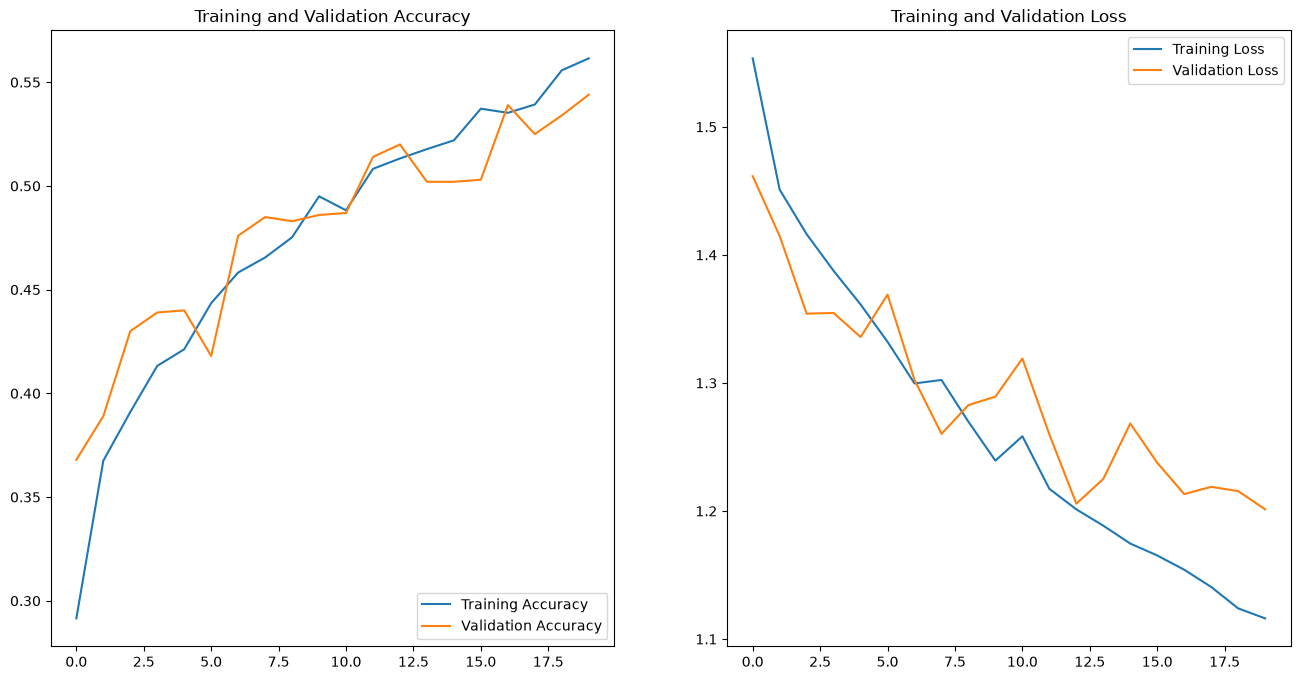

In [28]:
# VISUALIZE  RESULTS
vis_history(history4, 20)

### **QUESTION:** briefly discuss the results of the CNN with the different variations (with/without augmentation, with/without dropout). (maximum of 5 lines)

ANSWER: 

Without regularisation the model suffers a severe overfitting, memorizing the training dataset in the first ecpoches. 
When we add dropout to the last layers, we are capable of preventing the model to memorize the datasetforcint it to learn from the patterns. 
Then, we add data augmentation over this, that allows us to generate new artificial images that will help the model to learn new patterns as well. In this case we observed a limitation on the model, with even underfitting. 

Extra: As we saw underfitting, we tried with a new model with higher kernel sizes, but it still showed signs of underfitting. It's left to try to solve this classification with a more complex model. In both cases with augmentation the models were still learning in the last epoch, but due to time and resources limitations we didn't train them farther. 